## 不動産物件の価格推定

2025年度のデータをダウンロードしてモデルを作成

https://www.reinfolib.mlit.go.jp/realEstatePrices/

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
df = pd.read_csv(r"C:\Users\koyama\Downloads\Tokyo_20251_20254\Tokyo_20251_20254.csv", encoding="cp932")
df.head(2)

,種類,価格情報区分,地域,市区町村コード,都道府県名,市区町村名,地区名,最寄駅：名称,最寄駅：距離（分）,取引価格（総額）,...,用途,今後の利用目的,前面道路：方位,前面道路：種類,前面道路：幅員（ｍ）,都市計画,建ぺい率（％）,容積率（％）,取引時期,取引の事情等
0,宅地(土地と建物),不動産取引価格情報,商業地,13101,東京都,千代田区,飯田橋,飯田橋,0,340000000,...,住宅、店舗,店舗,北東,都道,27.0,商業,80.0,700.0,2025年第2四半期,NaN
1,宅地(土地),不動産取引価格情報,商業地,13101,東京都,千代田区,岩本町,岩本町,6,640000000,...,NaN,その他,南東,区道,6.0,商業,80.0,600.0,2025年第2四半期,NaN


In [4]:
df.columns

Index(['種類', '価格情報区分', '地域', '市区町村コード', '都道府県名', '市区町村名', '地区名', '最寄駅：名称',
       '最寄駅：距離（分）', '取引価格（総額）', '坪単価', '面積（㎡）', '取引価格（㎡単価）', '土地の形状', '間口',
       '延床面積（㎡）', '建築年', '建物の構造', '用途', '今後の利用目的', '前面道路：方位', '前面道路：種類',
       '前面道路：幅員（ｍ）', '都市計画', '建ぺい率（％）', '容積率（％）', '取引時期', '取引の事情等'],
      dtype='str')

In [5]:
df.shape

(20970, 28)

## 使用する変数の状況を確認し、前処理

In [6]:
df["建物の構造"].value_counts()

建物の構造
木造           14967
鉄骨造            768
ＲＣ             731
軽量鉄骨造          606
ＳＲＣ             74
ＲＣ、木造           37
鉄骨造、木造          18
ブロック造            6
ＲＣ、鉄骨造           4
ＳＲＣ、ＲＣ           3
木造、ブロック造         1
ＲＣ、軽量鉄骨造         1
木造、軽量鉄骨造         1
ＳＲＣ、鉄骨造          1
鉄骨造、軽量鉄骨造        1
Name: count, dtype: int64

In [7]:
df["前面道路：幅員（ｍ）"].isnull().sum()

np.int64(2957)

In [8]:
columns = [
    "取引価格（総額）",
    "地域",
    "市区町村名",
    "最寄駅：距離（分）",
    "面積（㎡）",
    "建築年",
    "前面道路：幅員（ｍ）"
]
df[columns]

,取引価格（総額）,地域,市区町村名,最寄駅：距離（分）,面積（㎡）,建築年,前面道路：幅員（ｍ）
0,340000000,商業地,千代田区,0,50,1954年,27.0
1,640000000,商業地,千代田区,6,180,NaN,6.0
2,780000000,商業地,千代田区,3,170,1982年,11.0
3,500000000,商業地,千代田区,5,105,NaN,8.0
4,1600000000,商業地,千代田区,3,185,1996年,11.0
...,...,...,...,...,...,...,...
20965,10000000,住宅地,八丈町,NaN,200,2000年,3.0
20966,5000000,商業地,八丈町,NaN,310,NaN,13.0
20967,550000,住宅地,八丈町,NaN,155,NaN,6.6
20968,4000000,住宅地,八丈町,NaN,890,1982年,5.5


In [14]:
# 0～5分、5～10分、10～20分、20～30分
df["最寄駅：距離（分）"].value_counts().sort_index()

最寄駅：距離（分）
0             9
1           116
10         3343
11          633
12          398
13          428
14          526
15         3174
16          336
17            9
18          288
19          230
1H30～2H      24
1H～1H30      86
2           281
20         1801
21          162
22            7
23          126
24           96
25          845
26           85
27            1
28           69
29           56
2H～          16
3           516
30分～60分     444
4           630
5          1683
6           843
7           665
8           835
9           795
Name: count, dtype: int64

In [15]:
from_station = df["最寄駅：距離（分）"].str.replace(r"^[01234]$", "0〜4分", regex=True)\
        .str.replace(r"^[56789]$$", "5〜9分", regex=True)\
        .str.replace(r"^1\d$", "10〜19分", regex=True)\
        .str.replace(r"^2\d$", "20〜29分", regex=True)
from_station = from_station.fillna("2H～")

In [16]:
# 島は除外、西多摩は統合
df["市区町村名"].value_counts()

市区町村名
練馬区         1434
世田谷区        1300
八王子市        1225
足立区         1142
杉並区         1041
大田区         1021
町田市          983
江戸川区         940
葛飾区          750
板橋区          721
中野区          510
府中市          496
北区           479
日野市          462
小平市          446
品川区          433
東村山市         407
調布市          403
立川市          388
西東京市         362
墨田区          328
目黒区          325
豊島区          320
江東区          312
東久留米市        308
荒川区          288
青梅市          270
三鷹市          263
新宿区          262
国分寺市         261
昭島市          255
あきる野市        235
文京区          221
東大和市         220
狛江市          192
渋谷区          185
清瀬市          184
小金井市         166
武蔵村山市        166
稲城市          163
台東区          147
多摩市          138
武蔵野市         131
国立市          127
港区           115
福生市          107
羽村市          102
西多摩郡瑞穂町       78
中央区           56
千代田区          36
西多摩郡日の出町      30
八丈町           10
西多摩郡奥多摩町       6
西多摩郡檜原村        4
大島町            4
新島村            4
神津島村           4
三宅村            3
小笠原村    

In [17]:
city = df["市区町村名"].str.replace(r"^西多摩郡.+", "西多摩郡", regex=True)\
                .str.replace(r".+[村町]$", "離島", regex=True)

In [18]:
df["建築年"].str.extract(r"(?P<建築年>\d+)年?").astype(float)

,建築年
0,1954.0
1,NaN
2,1982.0
3,NaN
4,1996.0
...,...
20965,2000.0
20966,NaN
20967,NaN
20968,1982.0


<Axes: ylabel='Frequency'>

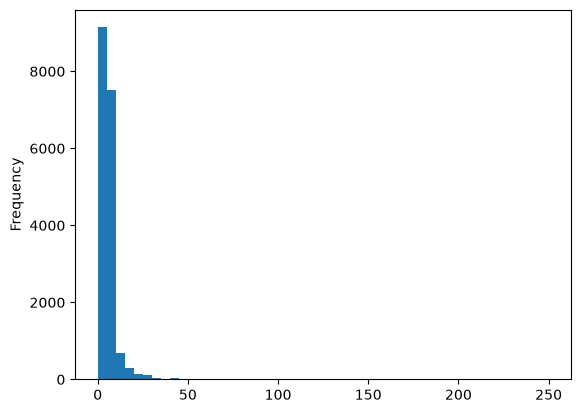

In [19]:
# 欠損処理
df["前面道路：幅員（ｍ）"].plot.hist(bins=50)

In [21]:
road = df["前面道路：幅員（ｍ）"].fillna(df["前面道路：幅員（ｍ）"].median())

In [22]:
road_cat = pd.cut(
    road,
    bins=[0, 5.5, np.inf],
    labels=["生活道路", "幹線道路"]
)

In [23]:
year = df["建築年"].str.extract(r"(?P<建築年>\d+)年").astype(float)

In [24]:
df["今後の利用目的"].value_counts()

今後の利用目的
住宅     8398
その他     915
事務所     225
店舗      212
倉庫       59
工場       29
Name: count, dtype: int64

In [25]:
df["取引の事情等"].value_counts()

取引の事情等
私道を含む取引            1366
隣地の購入                49
調停・競売等               41
関係者間取引               40
調停・競売等、私道を含む取引        7
隣地の購入、私道を含む取引         6
関係者間取引、私道を含む取引        3
私道を含む取引、その他事情有り       2
瑕疵有りの可能性              2
その他事情有り               1
Name: count, dtype: int64

In [26]:
df["前面道路：種類"].value_counts()

前面道路：種類
公道      5316
私道      5015
区道      4612
市道      2331
都道       429
道路       372
国道        73
町道        47
区画街路      29
村道        10
道道         3
農道         3
林道         2
県道         1
Name: count, dtype: int64

In [27]:
df["建物の構造"].value_counts()

建物の構造
木造           14967
鉄骨造            768
ＲＣ             731
軽量鉄骨造          606
ＳＲＣ             74
ＲＣ、木造           37
鉄骨造、木造          18
ブロック造            6
ＲＣ、鉄骨造           4
ＳＲＣ、ＲＣ           3
木造、ブロック造         1
ＲＣ、軽量鉄骨造         1
木造、軽量鉄骨造         1
ＳＲＣ、鉄骨造          1
鉄骨造、軽量鉄骨造        1
Name: count, dtype: int64

In [28]:
structure = df["建物の構造"]

In [30]:
remained = df.query("今後の利用目的 == '住宅'").dropna(subset="取引価格（㎡単価）")

## データセットの作成

In [31]:
y = remained["取引価格（㎡単価）"]
y.name = "price/area"

In [32]:
X = pd.concat(
    [from_station, city, road_cat],
    axis=1
).loc[y.index]
X.shape
X.columns = ["from_station", "city", "road"]

In [33]:
X.isnull().sum()

from_station    0
city            0
road            0
dtype: int64

In [34]:
X["from_station"].value_counts()

from_station
5〜9分       918
10〜19分     855
0〜4分       346
20〜29分     141
30分～60分     60
1H～1H30      9
1H30～2H      5
2H～          4
Name: count, dtype: int64

In [35]:
X["city"].value_counts()


city
世田谷区     202
大田区      185
杉並区      161
練馬区      125
八王子市      98
足立区       94
板橋区       91
品川区       88
町田市       83
中野区       76
目黒区       71
北区        63
葛飾区       63
荒川区       59
豊島区       58
江戸川区      52
立川市       52
江東区       46
府中市       45
文京区       44
新宿区       41
日野市       33
墨田区       32
昭島市       30
小平市       30
渋谷区       29
調布市       26
東村山市      25
国分寺市      25
台東区       24
国立市       24
三鷹市       21
港区        18
武蔵野市      18
青梅市       18
清瀬市       18
東久留米市     18
あきる野市     18
福生市       17
西東京市      15
西多摩郡      15
狛江市       14
羽村市       14
小金井市      12
武蔵村山市     12
東大和市      11
稲城市       11
千代田区       5
多摩市        5
中央区        2
離島         1
Name: count, dtype: int64

In [36]:
X["road"].value_counts()


road
生活道路    1601
幹線道路     737
Name: count, dtype: int64

In [37]:
X = X.query("city != '離島'")
y = y.loc[X.index]

In [38]:
print(X.shape, y.shape)

(2337, 3) (2337,)


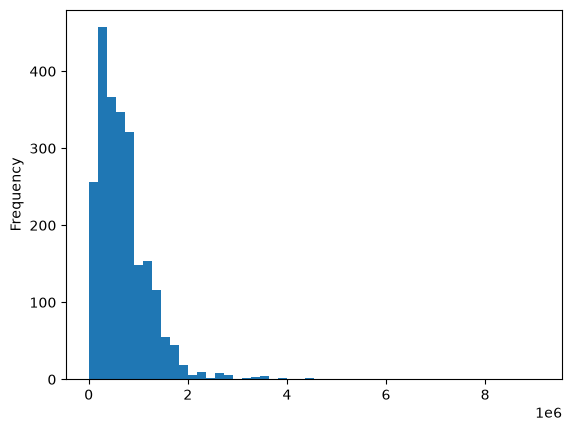

In [39]:
y.plot.hist(bins=50)
# plt.xscale("log")
plt.show()

## 線形回帰モデルの学習

In [40]:
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression


In [41]:
trans = OneHotEncoder(drop="first")
model = LinearRegression()
model.fit(trans.fit_transform(X), np.log10(y))

LinearRegression()

In [42]:
model.intercept_

np.float64(5.046309368774143)

In [43]:
model.coef_

array([-0.09558144, -0.87315622, -0.35808529, -0.19458539, -0.27910651,
       -0.33326085, -0.01343837,  0.83224867,  1.01224096,  1.38920253,
        0.98151634,  0.29793828,  0.87747574,  1.4889319 ,  1.18651234,
        1.05821486,  0.70698095,  0.66386979,  0.89562971,  0.39595096,
        0.8869886 ,  0.46941434,  0.76285963,  0.60695973,  1.21004821,
        1.15423477,  0.39137667,  0.43573585,  0.93465557,  0.56249783,
        0.39002434,  0.43130178,  0.82963588,  0.45900438,  0.92098428,
        0.69483148,  1.01409311,  0.52955883,  1.2850041 ,  1.40750508,
        0.63235195,  0.45959239,  1.12953658,  0.18013069,  0.46002593,
        0.5435553 ,  0.80250594,  0.19763534,  0.85823089,  0.68729033,
       -0.07318409,  0.61594414,  0.698693  ,  0.99975532,  0.62637393,
        0.08681555, -0.08711379])

In [44]:
trans.categories_

[array(['0〜4分', '10〜19分', '1H30～2H', '1H～1H30', '20〜29分', '2H～', '30分～60分',
        '5〜9分'], dtype=object),
 array(['あきる野市', '三鷹市', '世田谷区', '中央区', '中野区', '八王子市', '北区', '千代田区', '台東区',
        '品川区', '国分寺市', '国立市', '墨田区', '多摩市', '大田区', '小平市', '小金井市', '府中市',
        '文京区', '新宿区', '日野市', '昭島市', '杉並区', '東久留米市', '東大和市', '東村山市', '板橋区',
        '武蔵村山市', '武蔵野市', '江戸川区', '江東区', '清瀬市', '渋谷区', '港区', '狛江市', '町田市',
        '目黒区', '福生市', '稲城市', '立川市', '練馬区', '羽村市', '荒川区', '葛飾区', '西多摩郡',
        '西東京市', '調布市', '豊島区', '足立区', '青梅市'], dtype=object),
 array(['幹線道路', '生活道路'], dtype=object)]

In [45]:
trans.get_feature_names_out()

array(['from_station_10〜19分', 'from_station_1H30～2H',
       'from_station_1H～1H30', 'from_station_20〜29分', 'from_station_2H～',
       'from_station_30分～60分', 'from_station_5〜9分', 'city_三鷹市',
       'city_世田谷区', 'city_中央区', 'city_中野区', 'city_八王子市', 'city_北区',
       'city_千代田区', 'city_台東区', 'city_品川区', 'city_国分寺市', 'city_国立市',
       'city_墨田区', 'city_多摩市', 'city_大田区', 'city_小平市', 'city_小金井市',
       'city_府中市', 'city_文京区', 'city_新宿区', 'city_日野市', 'city_昭島市',
       'city_杉並区', 'city_東久留米市', 'city_東大和市', 'city_東村山市', 'city_板橋区',
       'city_武蔵村山市', 'city_武蔵野市', 'city_江戸川区', 'city_江東区', 'city_清瀬市',
       'city_渋谷区', 'city_港区', 'city_狛江市', 'city_町田市', 'city_目黒区',
       'city_福生市', 'city_稲城市', 'city_立川市', 'city_練馬区', 'city_羽村市',
       'city_荒川区', 'city_葛飾区', 'city_西多摩郡', 'city_西東京市', 'city_調布市',
       'city_豊島区', 'city_足立区', 'city_青梅市', 'road_生活道路'], dtype=object)

In [46]:
trans.drop_idx_

array([0, 0, 0], dtype=object)

In [47]:
list(map(lambda i_c:i_c[1][trans.drop_idx_[i_c[0]]], enumerate(trans.categories_)))

['0〜4分', 'あきる野市', '幹線道路']

In [48]:
pd.Series(model.coef_, index=trans.get_feature_names_out())

from_station_10〜19分    -0.095581
from_station_1H30～2H   -0.873156
from_station_1H～1H30   -0.358085
from_station_20〜29分    -0.194585
from_station_2H～       -0.279107
from_station_30分～60分   -0.333261
from_station_5〜9分      -0.013438
city_三鷹市                0.832249
city_世田谷区               1.012241
city_中央区                1.389203
city_中野区                0.981516
city_八王子市               0.297938
city_北区                 0.877476
city_千代田区               1.488932
city_台東区                1.186512
city_品川区                1.058215
city_国分寺市               0.706981
city_国立市                0.663870
city_墨田区                0.895630
city_多摩市                0.395951
city_大田区                0.886989
city_小平市                0.469414
city_小金井市               0.762860
city_府中市                0.606960
city_文京区                1.210048
city_新宿区                1.154235
city_日野市                0.391377
city_昭島市                0.435736
city_杉並区                0.934656
city_東久留米市              0.562498
city_東大和市 

## モデルの保存と使用

In [49]:
import pickle

with open("models.pkl", "wb") as f:
    pickle.dump(
        {
            "trans":trans,
            "model":model
        },
        f
    )

In [50]:
import pickle

with open("models.pkl", "rb") as f:
    models = pickle.load(f)

trans = models["trans"]
model = models["model"]

In [51]:
record = {"from_station":"5〜9分",
          "city": "新宿区",
          "road": "生活道路"}
X_test = pd.DataFrame([record])
X_test

,from_station,city,road
0,5〜9分,新宿区,生活道路


In [52]:
10 ** model.predict(
    trans.transform(X_test)
)

array([1258902.17831178])

## アプリ開発に必要な情報の表示

In [53]:
import sklearn
sklearn.__version__

'1.6.1'

In [54]:
trans.feature_names_in_

array(['from_station', 'city', 'road'], dtype=object)

In [55]:
trans.categories_

[array(['0〜4分', '10〜19分', '1H30～2H', '1H～1H30', '20〜29分', '2H～', '30分～60分',
        '5〜9分'], dtype=object),
 array(['あきる野市', '三鷹市', '世田谷区', '中央区', '中野区', '八王子市', '北区', '千代田区', '台東区',
        '品川区', '国分寺市', '国立市', '墨田区', '多摩市', '大田区', '小平市', '小金井市', '府中市',
        '文京区', '新宿区', '日野市', '昭島市', '杉並区', '東久留米市', '東大和市', '東村山市', '板橋区',
        '武蔵村山市', '武蔵野市', '江戸川区', '江東区', '清瀬市', '渋谷区', '港区', '狛江市', '町田市',
        '目黒区', '福生市', '稲城市', '立川市', '練馬区', '羽村市', '荒川区', '葛飾区', '西多摩郡',
        '西東京市', '調布市', '豊島区', '足立区', '青梅市'], dtype=object),
 array(['幹線道路', '生活道路'], dtype=object)]